## Classical ML Model #1: **Binomial Logistic Regression**


First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import numpy as np
import ast
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training

### **Training Set**: Binomial Logistic Regression

We are trying to predict if the our target class URB is rural or urban, 2 classes so a Binomial Logistic Regression is a natural pick. Let's first create our model using the the import from the sklearn library for our logistic Regression

In [2]:
# Logistic Regression (L2 Regularization) - Training Phase
from sklearn.linear_model import LogisticRegression

# Regularized logistic regression model
logreg_model = LogisticRegression(
    penalty="l2",       # regularization type (this is default)
    C=1.0,               # regularization strength (also a default)
    solver="lbfgs",     # optimizer (good default for larger datasets)
    max_iter=100,
    random_state=42
)

logreg_model.fit(X_train_scaled, y_train)

# Training-set predictions and probabilities
y_train_pred = logreg_model.predict(X_train_scaled)
y_train_proba = logreg_model.predict_proba(X_train_scaled)[:, 1]

c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


With our training split, we currently have **28119** rows. We will use **44** features to predict target feature `URB` whether its rural or urban. But why 88 features? We performed one-hot-encoding on 7 of our used features. `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Furthurmore, we remove the target column `URB`.

In [3]:
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Training features used: {X_train_scaled.shape[1]}")

Training samples: 28119
Training features used: 82


Let's now output our metrics. It is important to note that our classes are imbalanced. The entire dataset contains 40171 total number of entries. There are 15373 urban families and 24798 rural families.

In [4]:
from MCO_functions import report_binary_metrics, build_metric_series, highlight_val_train_row, run_logreg_validation_grid

train_report = report_binary_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    y_proba=y_train_proba,
    title="Training Metrics",
    n_iter=logreg_model.n_iter_,
)

cm_train = train_report["cm"]
cm_train_df = train_report["cm_df"]

Training Metrics (Overall)
Accuracy        : 0.8233
Balanced Acc    : 0.7994
ROC-AUC         : 0.8872
PR-AUC          : 0.8609
Log Loss        : 0.3934

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8279,0.8139
Recall,0.9011,0.6978
F1-score,0.8629,0.7514



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)           15641            1717
Actual Urban (1)            3252            7509

Iterations used: [100]


Our model used 96 iterations in the training set, lets visualize a graph of its loss to see how it improves

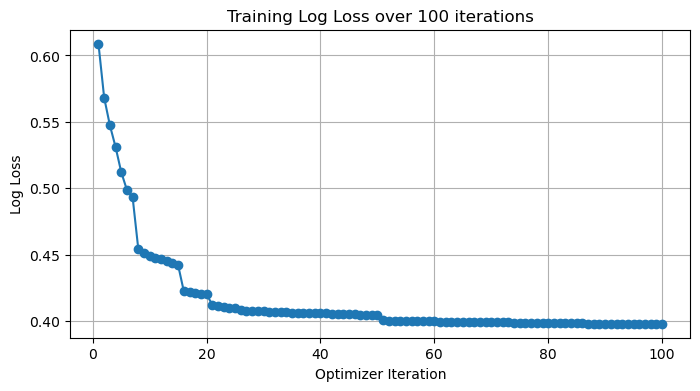

Showing first 10 and last 10 iterations out of 100 total:


,Optimizer Iteration,Train Log Loss
0,1,0.608857
1,2,0.568305
2,3,0.547595
3,4,0.531192
4,5,0.512223
5,6,0.498742
6,7,0.493249
7,8,0.454202
8,9,0.451429
9,10,0.449325


In [5]:
# Optional: inspect training loss over all optimizer iterations (reusable helper)
from MCO_functions import track_logreg_loss_by_iteration

# Track the same number of iterations used by the fitted training model
total_iters = int(np.ravel(logreg_model.n_iter_)[0])

loss_tracking = track_logreg_loss_by_iteration(
    X_train=X_train_scaled,
    y_train=y_train,
    total_iterations=total_iters,
    c=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight=None,
    random_state=42,
    head_n=10,
    tail_n=10,
    plot=True,
)

loss_history_df = loss_tracking["full_loss_df"]
loss_window_df = loss_tracking["compact_loss_df"]

print(f"Showing first 10 and last 10 iterations out of {total_iters} total:")
display(loss_window_df.style.format({"Train Log Loss": "{:.6f}"}))

# **[5]** Error Analysis and Model Tuning


### **Validation Set** (Pre-Tuned): Binomial Logistic Regression

Using our trained model, let's test it on the validation set. The validation set has **6026** rows of data

In [6]:
from MCO_functions import report_binary_metrics

# BEFORE TUNING: baseline validation metrics
y_val_pred = logreg_model.predict(X_val_scaled)
y_val_proba = logreg_model.predict_proba(X_val_scaled)[:, 1]

val_base_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    title="Current Validation Metrics (Before Tuning)",
)

cm_base = val_base_report["cm"]
cm_base_df = val_base_report["cm_df"]

Current Validation Metrics (Before Tuning) (Overall)
Accuracy        : 0.8108
Balanced Acc    : 0.7888
ROC-AUC         : 0.8768
PR-AUC          : 0.8470
Log Loss        : 0.4106

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8236,0.7858
Recall,0.8825,0.6951
F1-score,0.8521,0.7377



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3283             437
Actual Urban (1)             703            1603


Let's compare the model's performance with the training and validation set.

In [7]:
# Training vs Pre-Tuned Validation comparison with color highlights
metric_order = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

comparison_df = pd.concat(
    [
        build_metric_series(y_train, y_train_pred, y_train_proba, cm_train, metric_order).rename("Training"),
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order).rename("Pre-Tuned Validation"),
    ],
    axis=1,
)
comparison_df["Val - Train"] = comparison_df["Pre-Tuned Validation"] - comparison_df["Training"]

styled_comparison = (
    comparison_df.style
    .format(
        {
            "Training": "{:.4f}",
            "Pre-Tuned Validation": "{:.4f}",
            "Val - Train": "{:+.4f}",
        }
    )
    .apply(lambda row: highlight_val_train_row(row, direction_map, delta_col="Val - Train"), axis=1)
    .set_caption(
        "Training vs Pre-Tuned Validation Metrics "
        "(Val - Train color: green = better on validation given metric direction, red = worse, yellow = tie)"
    )
)

#### Validation set vs Training set

The behaviour is expected. Since the model still hasn't seen the validation set, a lower overall perfomance is expected.

In [8]:
print("Training vs Pre-Tuned Validation")
print("Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change")
display(styled_comparison)

Training vs Pre-Tuned Validation
Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change


,Training,Pre-Tuned Validation,Val - Train
Accuracy,0.8233,0.8108,-0.0125
Balanced Acc,0.7994,0.7888,-0.0106
Rural Precision,0.8279,0.8236,-0.0042
Rural Recall,0.9011,0.8825,-0.0186
Rural F1,0.8629,0.8521,-0.0109
Urban Precision,0.8139,0.7858,-0.0281
Urban Recall,0.6978,0.6951,-0.0027
Urban F1,0.7514,0.7377,-0.0137
ROC-AUC,0.8872,0.8768,-0.0104
PR-AUC,0.8609,0.8470,-0.0140


With that in mind, let's **fine-tune** our model

We will create a list of values per hyperparameters located in `run_logreg_validation_grid` function. The function iterates through the possible combinations/configurations of hyperparameters and chooses the best set of hyperparameters

We base our decision of the best (highest) `balanced accuracy` because of our high class imbalance, **38% Urban** and **61% Rural**.

### **Validation Set** (Tuned): Binomial Logistic Regression 

In [9]:
# Fine tuning our model with validation set
candidate_df = run_logreg_validation_grid(X_train_scaled, y_train, X_val_scaled, y_val)

print("\nValidation Tuning Results (top 5):")
display(candidate_df.head(5))

best = candidate_df.iloc[0]
best_c = float(best["C"])
best_solver = str(best["Solver"])
best_threshold = float(best["Threshold"])

if best["Class_Weight"] == "None":
    best_class_weight = None
elif best["Class_Weight"] == "balanced":
    best_class_weight = "balanced"
else:
    best_class_weight = ast.literal_eval(best["Class_Weight"])

print("\nBest validation configuration (Balanced):")
print(f"C            : {best_c}")
print(f"Solver       : {best_solver}")
print(f"Class Weight : {best_class_weight}")
print(f"Threshold    : {best_threshold}")

# Fit tuned model selected from validation ranking
logreg_model_tuned = LogisticRegression(
    penalty="l2",
    C=best_c,
    solver=best_solver,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)
logreg_model_tuned.fit(X_train_scaled, y_train)

y_val_proba_tuned = logreg_model_tuned.predict_proba(X_val_scaled)[:, 1]
y_val_pred_tuned = (y_val_proba_tuned >= best_threshold).astype(int)

c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_


Validation Tuning Results (top 5):


,C,Solver,Class_Weight,Threshold,Accuracy,Balanced_Acc,Rural_Acc,Urban_Acc,Rural_Precision,Rural_Recall,Rural_F1,Urban_Precision,Urban_Recall,Urban_F1,ROC_AUC,PR_AUC,LogLoss
0,30.0,lbfgs,"{0: 1.0, 1: 1.2}",0.41,0.800697,0.797779,0.810215,0.785343,0.858934,0.810215,0.833864,0.719507,0.785343,0.750985,0.876805,0.846907,0.413437
1,10.0,liblinear,"{0: 1.0, 1: 1.15}",0.40,0.800697,0.797696,0.810484,0.784909,0.858730,0.810484,0.833910,0.719682,0.784909,0.750882,0.876800,0.846940,0.412404
2,10.0,liblinear,"{0: 1.0, 1: 1.2}",0.41,0.800697,0.797696,0.810484,0.784909,0.858730,0.810484,0.833910,0.719682,0.784909,0.750882,0.876813,0.846886,0.413439
3,10.0,lbfgs,"{0: 1.0, 1: 1.15}",0.40,0.800697,0.797696,0.810484,0.784909,0.858730,0.810484,0.833910,0.719682,0.784909,0.750882,0.876802,0.846938,0.412402
4,30.0,liblinear,"{0: 1.2, 1: 1.0}",0.33,0.801527,0.797627,0.814247,0.781006,0.857102,0.814247,0.835125,0.722713,0.781006,0.750729,0.876641,0.847275,0.412108



Best validation configuration (Balanced):
C            : 30.0
Solver       : lbfgs
Class Weight : {0: 1.0, 1: 1.2}
Threshold    : 0.41


In [10]:
from MCO_functions import report_binary_metrics

val_tuned_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred_tuned,
    y_proba=y_val_proba_tuned,
    title="Tuned Model Validation Metrics",
    threshold=best_threshold,
    n_iter=logreg_model_tuned.n_iter_,
)

cm_tuned = val_tuned_report["cm"]
cm_tuned_df = val_tuned_report["cm_df"]

Tuned Model Validation Metrics (Overall)
Threshold used  : 0.41
Accuracy        : 0.8007
Balanced Acc    : 0.7978
ROC-AUC         : 0.8768
PR-AUC          : 0.8469
Log Loss        : 0.4134

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8589,0.7195
Recall,0.8102,0.7853
F1-score,0.8339,0.7510



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3014             706
Actual Urban (1)             495            1811

Iterations used: [334]


What hyperparameters changed during tuning?

In [11]:
print("\nWhat changed during tuning?")
print(f"- C: 1.0 -> {best_c}")
print(f"- Solver: lbfgs -> {best_solver}")
print(f"- Class weight: None -> {best_class_weight}")
print(f"- Decision threshold: 0.50 -> {best_threshold}")


What changed during tuning?
- C: 1.0 -> 30.0
- Solver: lbfgs -> lbfgs
- Class weight: None -> {0: 1.0, 1: 1.2}
- Decision threshold: 0.50 -> 0.41


Now let's check if the model's performance post-tuning improved againts pre-tuning

In [12]:
# Pre-tuned vs Post-tuned validation comparison (same style as earlier comparison table)
metric_order_tuning = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_tuning = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

tuned_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order_tuning).rename("Pre-Tuned Validation"),
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_tuning).rename("Post-Tuned Validation"),
    ],
    axis=1,
)
tuned_comparison_df["Post - Pre"] = (
    tuned_comparison_df["Post-Tuned Validation"] - tuned_comparison_df["Pre-Tuned Validation"]
)

styled_tuned_comparison = (
    tuned_comparison_df.style
    .format(
        {
            "Pre-Tuned Validation": "{:.4f}",
            "Post-Tuned Validation": "{:.4f}",
            "Post - Pre": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_tuning, delta_col="Post - Pre"),
        axis=1,
    )
    .set_caption(
        "Pre-Tuned vs Post-Tuned Validation Metrics "
        "(Post - Pre color: green = improved after tuning given metric direction, red = worse, yellow = tie)"
    )
)

print("Pre-Tuned vs Post-Tuned Validation")
print("Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change")
display(styled_tuned_comparison)

Pre-Tuned vs Post-Tuned Validation
Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change


,Pre-Tuned Validation,Post-Tuned Validation,Post - Pre
Accuracy,0.8108,0.8007,-0.0101
Balanced Acc,0.7888,0.7978,+0.0089
Rural Precision,0.8236,0.8589,+0.0353
Rural Recall,0.8825,0.8102,-0.0723
Rural F1,0.8521,0.8339,-0.0182
Urban Precision,0.7858,0.7195,-0.0663
Urban Recall,0.6951,0.7853,+0.0902
Urban F1,0.7377,0.7510,+0.0133
ROC-AUC,0.8768,0.8768,+0.0000
PR-AUC,0.8470,0.8469,-0.0001


# **[6]** Model Evaluation


### **Test Set**: Binomial Logistic Regression

The test split also contains **6026** entries of data.

In [13]:
from MCO_functions import report_binary_metrics

# Final Test-Set Evaluation (locked model from validation tuning)
# Use tuned model and tuned decision threshold selected on validation set
y_test_proba = logreg_model_tuned.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_report = report_binary_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    title="Final Test Metrics",
    threshold=best_threshold,
)

cm_test = test_report["cm"]
cm_test_df = test_report["cm_df"]

Final Test Metrics (Overall)
Threshold used  : 0.41
Accuracy        : 0.7995
Balanced Acc    : 0.7950
ROC-AUC         : 0.8833
PR-AUC          : 0.8537
Log Loss        : 0.4028

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8542,0.7214
Recall,0.8142,0.7758
F1-score,0.8337,0.7476



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3029             691
Actual Urban (1)             517            1789


Now let's compare the model's performance on the test and post-tuning validation sets

In [14]:
# Post-tuned validation vs Test-set comparison (same style as earlier comparison table)
metric_order_test = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_test = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

test_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_test).rename("Post-Tuned Validation"),
        build_metric_series(y_test, y_test_pred, y_test_proba, cm_test, metric_order_test).rename("Test Set"),
    ],
    axis=1,
)
test_comparison_df["Test - Post"] = (
    test_comparison_df["Test Set"] - test_comparison_df["Post-Tuned Validation"]
)

styled_test_comparison = (
    test_comparison_df.style
    .format(
        {
            "Post-Tuned Validation": "{:.4f}",
            "Test Set": "{:.4f}",
            "Test - Post": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_test, delta_col="Test - Post"),
        axis=1,
    )
    .set_caption(
        "Post-Tuned Validation vs Test-Set Metrics "
        "(Test - Post color: green = improved on test given metric direction, red = worse, yellow = tie)"
    )
)

print("Post-Tuned Validation vs Test Set")
print("Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change")
display(styled_test_comparison)

Post-Tuned Validation vs Test Set
Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change


,Post-Tuned Validation,Test Set,Test - Post
Accuracy,0.8007,0.7995,-0.0012
Balanced Acc,0.7978,0.7950,-0.0028
Rural Precision,0.8589,0.8542,-0.0047
Rural Recall,0.8102,0.8142,+0.0040
Rural F1,0.8339,0.8337,-0.0001
Urban Precision,0.7195,0.7214,+0.0019
Urban Recall,0.7853,0.7758,-0.0095
Urban F1,0.7510,0.7476,-0.0034
ROC-AUC,0.8768,0.8833,+0.0065
PR-AUC,0.8469,0.8537,+0.0068


In [ ]:
import os

os.makedirs('model_outputs', exist_ok=True)

# Save the final locked-in tuned model
joblib.dump(logreg_model_tuned, 'model_outputs/logistic_regression_final_model.pkl')
joblib.dump(best_threshold, 'model_outputs/logistic_regression_threshold.pkl')

# Create a DataFrame of the test-set predictions and probabilities
lg_test_results = pd.DataFrame({
    'Actual_y_test': y_test,
    'LG_Predicted_Class': y_test_pred,
    'LG_Predicted_Probability': logreg_model_tuned.predict_proba(X_test_scaled)[:, 1],
})

# Export to CSV for easy comparison in the main directory
lg_test_results.to_csv('model_outputs/lg_test_predictions.csv', index=False)